# EfficientNetB0 from scratch pour Pneumonia

Ce notebook entraîne un modèle **EfficientNetB0** sans transfer learning (aucun poids pré-entraîné) pour classifier les radios thoraciques en trois classes : **normal**, **bacteria**, **virus**.

In [7]:
import os
import time
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Configuration du device + hyperparamètres (sans gestion des données ici)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparamètres du modèle / entraînement
NUM_CLASSES = 3           # normal, bacteria, virus
learning_rate = 1e-3      # plus élevé que TL
num_epochs = 20           # plus d'époques que TL

# Chemin pour sauvegarder le meilleur modèle (à adapter si tu veux)
checkpoint_path = "efficientnet_b0_from_scratch_best.pt"
print("Checkpoint path :", checkpoint_path)

Using device: cuda
Checkpoint path : efficientnet_b0_from_scratch_best.pt


Libraries imported successfully!

Augmentation pipelines created!

Loading dataset...

  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images

 Transforms applied!
 Images will be augmented on-the-fly when you load them


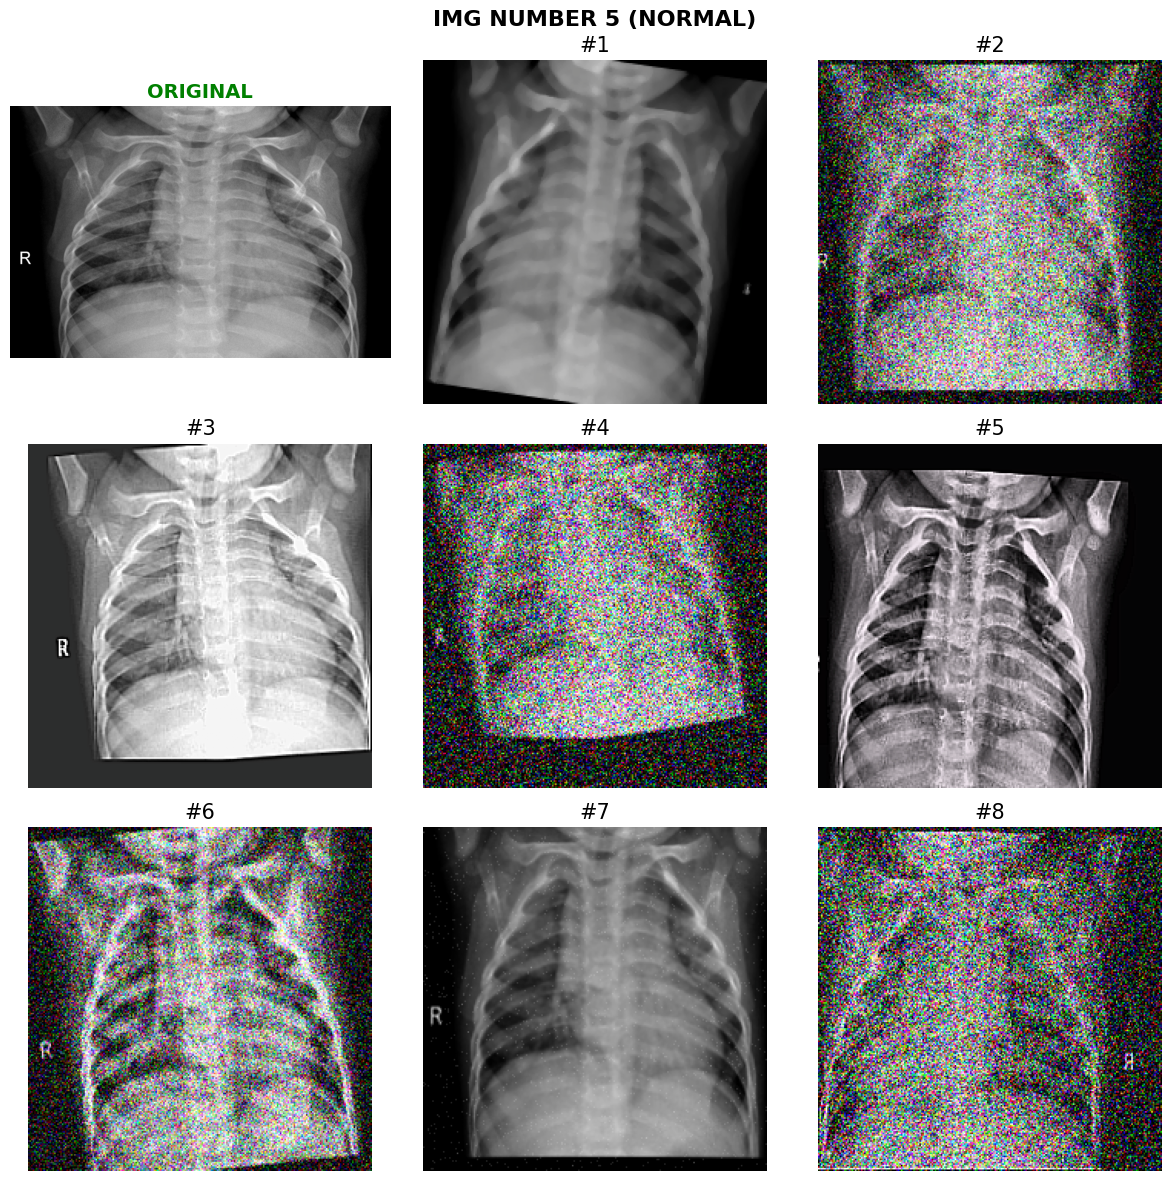


  DataLoaders ready!
  Batch size: 32
  Train batches: 148
  Val batches: 17
  Test batches: 20
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First 10 labels: [1, 1, 1, 1, 1, 2, 1, 0, 1, 1]
Label distribution: [8, 20, 4]


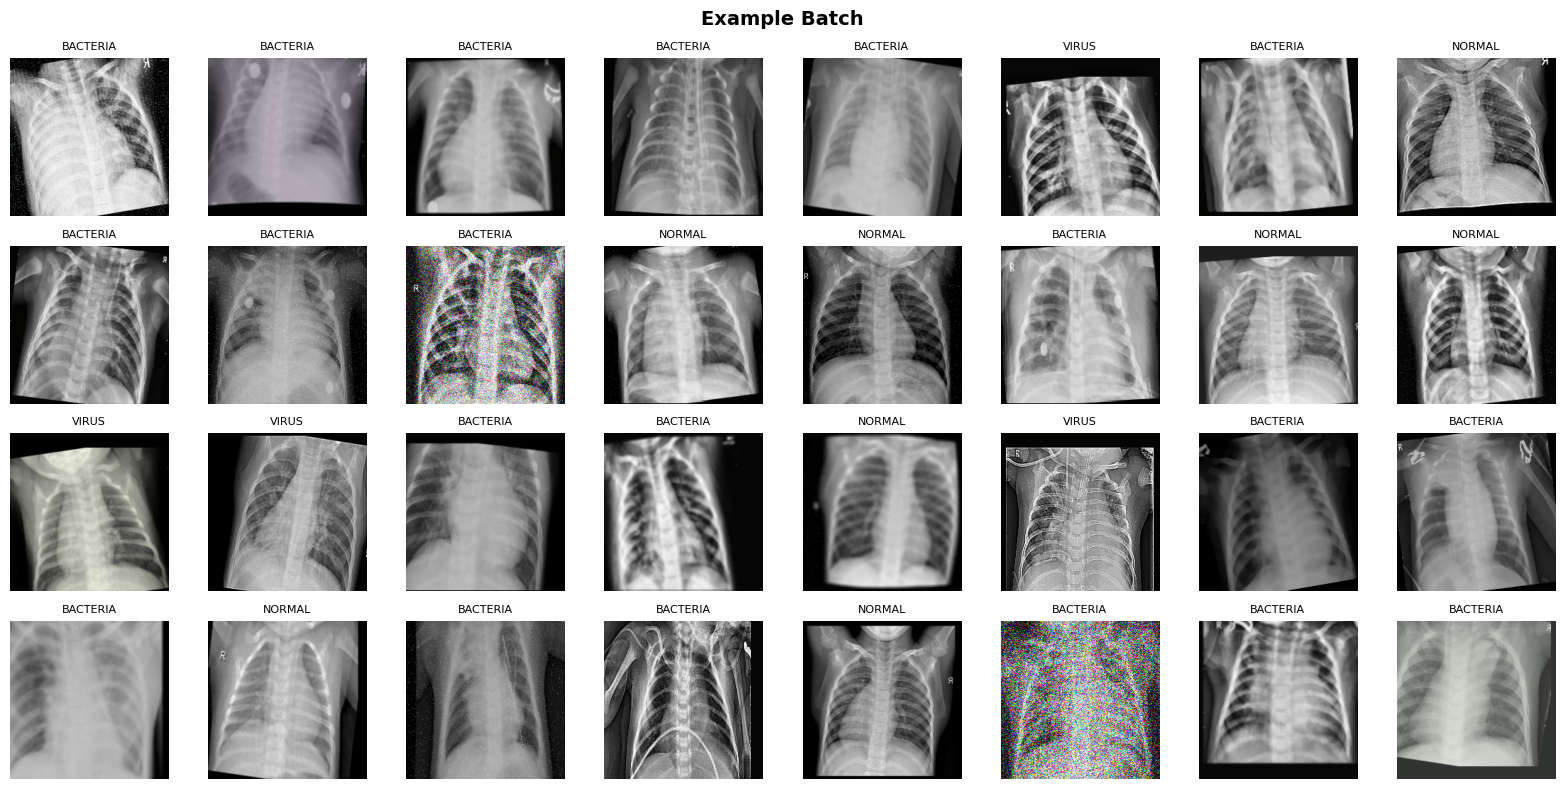


Taille train_loader : 148
Taille val_loader   : 17
Taille test_loader  : 20


In [9]:
# Appel direct du notebook de préprocessing
# (il prépare dataset, augmentations et DataLoaders : train_loader, val_loader, test_loader)

%run ../../prepocessing.ipynb

print("\nTaille train_loader :", len(train_loader))
print("Taille val_loader   :", len(val_loader))
print("Taille test_loader  :", len(test_loader))

# Noms de classes pour les rapports
class_names = ["NORMAL", "BACTERIA", "VIRUS"]

In [10]:
# Modèle EfficientNetB0 from scratch (aucun poids pré-entraîné)

model = efficientnet_b0(weights=None)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("EfficientNetB0 (from scratch) initialisé pour", NUM_CLASSES, "classes.")

EfficientNetB0 (from scratch) initialisé pour 3 classes.


In [11]:
# Fonctions d'entraînement et de validation

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for batch in loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total

    return epoch_loss, epoch_acc

In [12]:
# Boucle d'entraînement principale + sauvegarde du meilleur modèle

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

start_time = time.time()

for epoch in range(1, num_epochs + 1):
    print(f"\n===== Epoch {epoch}/{num_epochs} =====")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train loss: {train_loss:.4f}  |  Train acc: {train_acc:.4f}")
    print(f"Val   loss: {val_loss:.4f}  |  Val   acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, checkpoint_path)
        print(f"--> Nouveau meilleur modèle sauvegardé (val_acc = {best_val_acc:.4f})")

total_time = time.time() - start_time
print(f"\nEntraînement terminé en {total_time/60:.1f} minutes.")
print(f"Meilleure val_acc : {best_val_acc:.4f}")


===== Epoch 1/20 =====
Train loss: 1.0389  |  Train acc: 0.5103
Val   loss: 0.9182  |  Val   acc: 0.5690
--> Nouveau meilleur modèle sauvegardé (val_acc = 0.5690)

===== Epoch 2/20 =====
Train loss: 0.8716  |  Train acc: 0.6057
Val   loss: 0.7547  |  Val   acc: 0.5977
--> Nouveau meilleur modèle sauvegardé (val_acc = 0.5977)

===== Epoch 3/20 =====
Train loss: 0.7624  |  Train acc: 0.6514
Val   loss: 0.6181  |  Val   acc: 0.6398
--> Nouveau meilleur modèle sauvegardé (val_acc = 0.6398)

===== Epoch 4/20 =====


KeyboardInterrupt: 

In [ ]:
# Sauvegarde des résultats dans un JSON (sans écraser les runs précédents)

import json
from datetime import datetime

results_path = "results_history.json"

# Charger l'historique existant s'il existe
if os.path.exists(results_path):
    with open(results_path, "r") as f:
        all_runs = json.load(f)
else:
    all_runs = []

# Créer l'entrée pour ce run
run_entry = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "params": {
        "model": "EfficientNetB0",
        "transfer_learning": False,
        "num_classes": NUM_CLASSES,
        "learning_rate": learning_rate,
        "num_epochs": num_epochs,
        "batch_size": train_loader.batch_size,
    },
    "best_val_acc": best_val_acc,
    "total_time_min": round(total_time / 60, 1),
    "history": history,
}

all_runs.append(run_entry)

with open(results_path, "w") as f:
    json.dump(all_runs, f, indent=2)

print(f"Run #{len(all_runs)} sauvegardé dans {results_path}")

In [ ]:
# Visualisation des courbes de loss / accuracy

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train")
plt.plot(epochs_range, history["val_loss"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train")
plt.plot(epochs_range, history["val_acc"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Chargement du meilleur modèle et évaluation sur le test

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model = model.to(device)
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

print("Classification report :")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prédit")
plt.ylabel("Vrai")
plt.title("Matrice de confusion (test)")
plt.tight_layout()
plt.show()